In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('QVI_data.csv')

In [4]:
data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,17-10-2018,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,16-09-2018,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,07-03-2019,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,08-03-2019,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,02-11-2018,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [5]:
data.shape

(264834, 12)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


In [7]:
data.describe()

,LYLTY_CARD_NBR,STORE_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,2.648340e+05,264834.000000,2.648340e+05,264834.000000,264834.000000,264834.000000,264834.000000
mean,1.355488e+05,135.079423,1.351576e+05,56.583554,1.905813,7.299346,182.425512
std,8.057990e+04,76.784063,7.813292e+04,32.826444,0.343436,2.527241,64.325148
min,1.000000e+03,1.000000,1.000000e+00,1.000000,1.000000,1.500000,70.000000
25%,7.002100e+04,70.000000,6.760050e+04,28.000000,2.000000,5.400000,150.000000
50%,1.303570e+05,130.000000,1.351365e+05,56.000000,2.000000,7.400000,170.000000
75%,2.030940e+05,203.000000,2.026998e+05,85.000000,2.000000,9.200000,175.000000
max,2.373711e+06,272.000000,2.415841e+06,114.000000,5.000000,29.500000,380.000000


In [8]:
data.columns

Index(['LYLTY_CARD_NBR', 'DATE', 'STORE_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND', 'LIFESTAGE',
       'PREMIUM_CUSTOMER'],
      dtype='object')

In [9]:
data.isnull().sum()

LYLTY_CARD_NBR      0
DATE                0
STORE_NBR           0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [10]:
data.duplicated().sum()

np.int64(1)

In [11]:
data = data.drop_duplicates()

In [12]:
data.duplicated().sum()

np.int64(0)

In [13]:
data["DATE"] = pd.to_datetime(data["DATE"], dayfirst=True)   #Converting date to datetime datatype

# Feature Egineering

In [14]:
#Let's create MONTH column
# Create Month Identifier
data["MONTH_ID"] = data["DATE"].dt.to_period("M")

In [15]:
data[["DATE", "MONTH_ID"]].head()

,DATE,MONTH_ID
0,2018-10-17,2018-10
1,2018-09-16,2018-09
2,2019-03-07,2019-03
3,2019-03-08,2019-03
4,2018-11-02,2018-11


In [16]:
monthly_metrics = (
    data.groupby(["STORE_NBR", "MONTH_ID"]).agg(
        Total_Sales=("TOT_SALES", "sum"),
        Total_Customers=("LYLTY_CARD_NBR", "nunique"),
        Total_Transactions=("TXN_ID", "nunique"),
        Total_Units=("PROD_QTY", "sum")
    ).reset_index()
)

monthly_metrics["Avg_Transactions_Per_Customer"] = (
    monthly_metrics["Total_Transactions"] /
    monthly_metrics["Total_Customers"]
)

monthly_metrics.head()

,STORE_NBR,MONTH_ID,Total_Sales,Total_Customers,Total_Transactions,Total_Units,Avg_Transactions_Per_Customer
0,1,2018-07,206.9,49,52,62,1.061224
1,1,2018-08,176.1,42,43,54,1.023810
2,1,2018-09,278.8,59,62,75,1.050847
3,1,2018-10,188.1,44,45,58,1.022727
4,1,2018-11,192.6,46,47,57,1.021739


In [17]:
monthly_metrics.head()

,STORE_NBR,MONTH_ID,Total_Sales,Total_Customers,Total_Transactions,Total_Units,Avg_Transactions_Per_Customer
0,1,2018-07,206.9,49,52,62,1.061224
1,1,2018-08,176.1,42,43,54,1.023810
2,1,2018-09,278.8,59,62,75,1.050847
3,1,2018-10,188.1,44,45,58,1.022727
4,1,2018-11,192.6,46,47,57,1.021739


In [18]:
monthly_metrics.shape

(3169, 7)

In [19]:
# Now differentiate betwen traial and pre trials

In [20]:
# INclude ONly pre-trial data
pre_trial = monthly_metrics[
    monthly_metrics["MONTH_ID"] < pd.Period("2019-02", freq="M")
]

pre_trial.head(10)

,STORE_NBR,MONTH_ID,Total_Sales,Total_Customers,Total_Transactions,Total_Units,Avg_Transactions_Per_Customer
0,1,2018-07,206.9,49,52,62,1.061224
1,1,2018-08,176.1,42,43,54,1.023810
2,1,2018-09,278.8,59,62,75,1.050847
3,1,2018-10,188.1,44,45,58,1.022727
4,1,2018-11,192.6,46,47,57,1.021739
5,1,2018-12,189.6,42,47,57,1.119048
6,1,2019-01,154.8,35,36,42,1.028571
12,2,2018-07,150.8,39,41,46,1.051282
13,2,2018-08,193.8,39,43,55,1.102564
14,2,2018-09,154.4,36,37,41,1.027778


In [21]:
pre_trial['MONTH_ID'].unique()

<PeriodArray>
['2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01']
Length: 7, dtype: period[M]

In [22]:
monthly_metrics.head()

,STORE_NBR,MONTH_ID,Total_Sales,Total_Customers,Total_Transactions,Total_Units,Avg_Transactions_Per_Customer
0,1,2018-07,206.9,49,52,62,1.061224
1,1,2018-08,176.1,42,43,54,1.023810
2,1,2018-09,278.8,59,62,75,1.050847
3,1,2018-10,188.1,44,45,58,1.022727
4,1,2018-11,192.6,46,47,57,1.021739


In [23]:
monthly_metrics["MONTH_ID"].unique()

<PeriodArray>
['2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01',
 '2019-02', '2019-03', '2019-04', '2019-05', '2019-06']
Length: 12, dtype: period[M]

In [24]:
# Keep only stores having all 7 pre-trial months
pre_trial_complete = (
    pre_trial.groupby("STORE_NBR")
    .filter(lambda store: len(store) == 7)
)

In [25]:
import numpy as np

def calculate_correlation(series1, series2):
    """
    Calculate Pearson correlation between two pandas Series.
    Returns None if correlation cannot be computed.
    """

    series1 = series1.reset_index(drop=True)
    series2 = series2.reset_index(drop=True)

    # Pearson correlation is undefined if either series
    # has no variation.
    if np.isclose(series1.std(), 0) or np.isclose(series2.std(), 0):
        return None

    return series1.corr(series2)

In [26]:
def calculate_average_distance(series1, series2):
    """
    Calculate average absolute distance between two series.
    """

    series1 = series1.reset_index(drop=True)
    series2 = series2.reset_index(drop=True)

    return (series1 - series2).abs().mean()

In [27]:
def calculate_magnitude_similarity(observed_distance,
                                   min_distance,
                                   max_distance):
    """
    Convert distance into similarity score.
    """

    if np.isclose(max_distance, min_distance):
        return 1

    return 1 - (
        (observed_distance - min_distance)
        /
        (max_distance - min_distance)
    )

In [28]:
def compare_two_stores(trial_store_number,
                       candidate_store_number):

    """
    Compare one trial store with one candidate store.
    """

    trial_store = pre_trial_complete[
        pre_trial_complete["STORE_NBR"] == trial_store_number
    ]

    candidate_store = pre_trial_complete[
        pre_trial_complete["STORE_NBR"] == candidate_store_number
    ]

    sales_corr = calculate_correlation(
        trial_store["Total_Sales"],
        candidate_store["Total_Sales"]
    )

    customer_corr = calculate_correlation(
        trial_store["Total_Customers"],
        candidate_store["Total_Customers"]
    )

    transaction_corr = calculate_correlation(
        trial_store["Avg_Transactions_Per_Customer"],
        candidate_store["Avg_Transactions_Per_Customer"]
    )

    # If any metric cannot be compared,
    # ignore this candidate.
    if (
        sales_corr is None or
        customer_corr is None or
        transaction_corr is None
    ):
        return None

    sales_distance = calculate_average_distance(
        trial_store["Total_Sales"],
        candidate_store["Total_Sales"]
    )

    customer_distance = calculate_average_distance(
        trial_store["Total_Customers"],
        candidate_store["Total_Customers"]
    )

    transaction_distance = calculate_average_distance(
        trial_store["Avg_Transactions_Per_Customer"],
        candidate_store["Avg_Transactions_Per_Customer"]
    )

    return {

        "Trial_Store": trial_store_number,
        "Candidate_Store": candidate_store_number,

        "Sales_Correlation": sales_corr,
        "Customer_Correlation": customer_corr,
        "Transaction_Correlation": transaction_corr,

        "Sales_Distance": sales_distance,
        "Customer_Distance": customer_distance,
        "Transaction_Distance": transaction_distance

    }

In [29]:
def find_control_store(trial_store_number):
    """
    Find the best control stores for a given trial store using
    pre-trial data.

    Steps:
    1. Compare the trial store with every eligible candidate store.
    2. Calculate correlation and average distance for each metric.
    3. Convert distance into magnitude similarity.
    4. Calculate overall similarity score.
    5. Rank candidate stores by overall similarity.

    Parameters
    ----------
    trial_store_number : int
        Trial store number.

    Returns
    -------
    pandas.DataFrame
        Ranked comparison table for all candidate stores.
    """

    # --------------------------------------------------
    # Store comparison results
    # --------------------------------------------------

    comparison_results = []

    # --------------------------------------------------
    # Get all eligible candidate stores
    # --------------------------------------------------

    candidate_stores = pre_trial_complete[
        pre_trial_complete["STORE_NBR"] != trial_store_number
    ]["STORE_NBR"].unique()

    # --------------------------------------------------
    # Compare trial store with every candidate store
    # --------------------------------------------------

    for candidate_store in candidate_stores:

        result = compare_two_stores(
            trial_store_number,
            candidate_store
        )

        # Ignore stores that cannot be compared
        if result is not None:
            comparison_results.append(result)

    # --------------------------------------------------
    # Convert comparison results into DataFrame
    # --------------------------------------------------

    comparison_df = pd.DataFrame(comparison_results)

    # --------------------------------------------------
    # Find minimum and maximum distance for each metric
    # --------------------------------------------------

    sales_min = comparison_df["Sales_Distance"].min()
    sales_max = comparison_df["Sales_Distance"].max()

    customer_min = comparison_df["Customer_Distance"].min()
    customer_max = comparison_df["Customer_Distance"].max()

    transaction_min = comparison_df["Transaction_Distance"].min()
    transaction_max = comparison_df["Transaction_Distance"].max()

    # --------------------------------------------------
    # Calculate Sales Magnitude Similarity
    # --------------------------------------------------

    comparison_df["Sales_Magnitude"] = comparison_df[
        "Sales_Distance"
    ].apply(
        lambda distance: calculate_magnitude_similarity(
            distance,
            sales_min,
            sales_max
        )
    )

    # --------------------------------------------------
    # Calculate Customer Magnitude Similarity
    # --------------------------------------------------

    comparison_df["Customer_Magnitude"] = comparison_df[
        "Customer_Distance"
    ].apply(
        lambda distance: calculate_magnitude_similarity(
            distance,
            customer_min,
            customer_max
        )
    )

    # --------------------------------------------------
    # Calculate Transaction Magnitude Similarity
    # --------------------------------------------------

    comparison_df["Transaction_Magnitude"] = comparison_df[
        "Transaction_Distance"
    ].apply(
        lambda distance: calculate_magnitude_similarity(
            distance,
            transaction_min,
            transaction_max
        )
    )

    # --------------------------------------------------
    # Calculate Overall Similarity Score
    # --------------------------------------------------

    comparison_df["Overall_Similarity"] = (

        comparison_df["Sales_Correlation"] +
        comparison_df["Customer_Correlation"] +
        comparison_df["Transaction_Correlation"] +

        comparison_df["Sales_Magnitude"] +
        comparison_df["Customer_Magnitude"] +
        comparison_df["Transaction_Magnitude"]

    ) / 6

    # --------------------------------------------------
    # Rank candidate stores by similarity
    # --------------------------------------------------

    comparison_df = comparison_df.sort_values(
        by="Overall_Similarity",
        ascending=False
    ).reset_index(drop=True)

    return comparison_df.head()

In [30]:
control_77 = find_control_store(77)

control_86 = find_control_store(86)

control_88 = find_control_store(88)

In [31]:
control_77

,Trial_Store,Candidate_Store,Sales_Correlation,Customer_Correlation,Transaction_Correlation,Sales_Distance,Customer_Distance,Transaction_Distance,Sales_Magnitude,Customer_Magnitude,Transaction_Magnitude,Overall_Similarity
0,77,17,0.842668,0.747308,0.423245,155.614286,3.571429,0.034026,0.886125,0.969136,0.945539,0.802337
1,77,84,0.684348,0.858571,0.396508,219.928571,7.428571,0.034129,0.832583,0.927469,0.945114,0.774099
2,77,145,0.430642,0.681155,0.601015,80.971429,4.428571,0.029635,0.948266,0.959877,0.963784,0.764123
3,77,115,0.689159,0.718882,0.303872,87.657143,3.428571,0.034434,0.942700,0.970679,0.943845,0.761523
4,77,37,0.437596,0.494016,0.715181,170.478571,7.285714,0.021669,0.873750,0.929012,0.996878,0.741072


In [32]:
trial_77_control = int(control_77.iloc[0]["Candidate_Store"])
trial_86_control = int(control_86.iloc[0]["Candidate_Store"])
trial_88_control = int(control_88.iloc[0]["Candidate_Store"])

print("Control Store for Trial 77 :", trial_77_control)
print("Control Store for Trial 86 :", trial_86_control)
print("Control Store for Trial 88 :", trial_88_control)

Control Store for Trial 77 : 17
Control Store for Trial 86 : 138
Control Store for Trial 88 : 178


In [33]:
def analyze_trial_store(control_store_table):
    """
    Analyze the performance of a trial store against its best control store.

    Parameters
    ----------
    control_store_table : pandas.DataFrame
        Output from find_control_store().

    Returns
    -------
    pandas.DataFrame
        Summary table comparing pre-trial and trial performance.
    """

    # --------------------------------------------------
    # Get trial and control store numbers
    # --------------------------------------------------

    trial_store = int(control_store_table.iloc[0]["Trial_Store"])
    control_store = int(control_store_table.iloc[0]["Candidate_Store"])

    # --------------------------------------------------
    # Split pre-trial and trial data
    # --------------------------------------------------

    pre_trial = monthly_metrics[
        monthly_metrics["MONTH_ID"] < pd.Period("2019-02", freq="M")
    ]

    trial_period = monthly_metrics[
        monthly_metrics["MONTH_ID"] >= pd.Period("2019-02", freq="M")
    ]

    # --------------------------------------------------
    # Trial Store Data
    # --------------------------------------------------

    trial_pre = pre_trial[
        pre_trial["STORE_NBR"] == trial_store
    ]

    trial_after = trial_period[
        trial_period["STORE_NBR"] == trial_store
    ]

    # --------------------------------------------------
    # Control Store Data
    # --------------------------------------------------

    control_pre = pre_trial[
        pre_trial["STORE_NBR"] == control_store
    ]

    control_after = trial_period[
        trial_period["STORE_NBR"] == control_store
    ]

    # --------------------------------------------------
    # Calculate average metrics
    # --------------------------------------------------

    summary = pd.DataFrame({

        "Metric": [
            "Total Sales",
            "Total Customers",
            "Avg Transactions per Customer"
        ],

        "Trial_Pre": [

            trial_pre["Total_Sales"].mean(),

            trial_pre["Total_Customers"].mean(),

            trial_pre["Avg_Transactions_Per_Customer"].mean()

        ],

        "Trial_After": [

            trial_after["Total_Sales"].mean(),

            trial_after["Total_Customers"].mean(),

            trial_after["Avg_Transactions_Per_Customer"].mean()

        ],

        "Control_Pre": [

            control_pre["Total_Sales"].mean(),

            control_pre["Total_Customers"].mean(),

            control_pre["Avg_Transactions_Per_Customer"].mean()

        ],

        "Control_After": [

            control_after["Total_Sales"].mean(),

            control_after["Total_Customers"].mean(),

            control_after["Avg_Transactions_Per_Customer"].mean()

        ]

    })

    # --------------------------------------------------
    # Calculate Growth (%)
    # --------------------------------------------------

    summary["Trial_Growth_%"] = (
        (
            summary["Trial_After"] -
            summary["Trial_Pre"]
        )
        /
        summary["Trial_Pre"]
    ) * 100

    summary["Control_Growth_%"] = (
        (
            summary["Control_After"] -
            summary["Control_Pre"]
        )
        /
        summary["Control_Pre"]
    ) * 100

    # --------------------------------------------------
    # Extra Growth due to Trial
    # --------------------------------------------------

    summary["Trial_Impact_%"] = (
        summary["Trial_Growth_%"] -
        summary["Control_Growth_%"]
    )

    summary = summary.round(2)

    print("=" * 70)
    print(f"Trial Store   : {trial_store}")
    print(f"Control Store : {control_store}")
    print("=" * 70)

    return summary

In [34]:
analyze_trial_store(control_77)

Trial Store   : 77
Control Store : 17


,Metric,Trial_Pre,Trial_After,Control_Pre,Control_After,Trial_Growth_%,Control_Growth_%,Trial_Impact_%
0,Total Sales,242.71,268.20,398.33,369.66,10.50,-7.20,17.70
1,Total Customers,42.71,47.60,43.71,43.40,11.44,-0.72,12.16
2,Avg Transactions per Customer,1.06,1.03,1.06,1.04,-2.38,-1.82,-0.55


In [35]:
analyze_trial_store(control_86)

Trial Store   : 86
Control Store : 138


,Metric,Trial_Pre,Trial_After,Control_Pre,Control_After,Trial_Growth_%,Control_Growth_%,Trial_Impact_%
0,Total Sales,874.26,903.10,903.29,900.36,3.30,-0.32,3.62
1,Total Customers,99.57,105.80,102.57,104.40,6.26,1.78,4.47
2,Avg Transactions per Customer,1.26,1.23,1.26,1.27,-2.27,0.30,-2.57


In [36]:
analyze_trial_store(control_88)

Trial Store   : 88
Control Store : 178


,Metric,Trial_Pre,Trial_After,Control_Pre,Control_After,Trial_Growth_%,Control_Growth_%,Trial_Impact_%
0,Total Sales,1340.51,1389.93,934.93,951.60,3.69,1.78,1.90
1,Total Customers,125.71,127.00,103.57,106.40,1.02,2.73,-1.71
2,Avg Transactions per Customer,1.22,1.24,1.27,1.27,1.62,-0.58,2.20


# Step 6: Business Conclusions



## Trial Store 77

### Observation
- Total Sales increased by **10.50%** in the trial store, while the control store experienced a **7.20% decrease**, resulting in a positive trial impact of **17.70%**.
- Total Customers increased by **11.44%** in the trial store, whereas the control store showed a slight decrease of **0.72%**, giving a positive customer impact of **12.16%**.
- Average Transactions per Customer decreased slightly in both stores. The trial store decreased by **2.38%**, while the control store decreased by **1.82%**, indicating no meaningful improvement in transaction frequency.

### Conclusion
The new store layout appears to have had a **positive impact on Store 77**. The trial store demonstrated substantial improvements in both sales and customer count compared to its control store. Although transaction frequency per customer remained largely unchanged, the increase in sales was primarily driven by attracting more customers. Overall, the trial for Store 77 can be considered **successful**.

## Trial Store 86

### Observation
- Total Sales increased by **3.30%** in the trial store, while the control store decreased slightly by **0.32%**, resulting in a positive impact of **3.62%**.
- Total Customers increased by **6.26%** in the trial store compared to a **1.78%** increase in the control store, producing a positive impact of **4.47%**.
- Average Transactions per Customer decreased by **2.27%** in the trial store, while the control store experienced a slight increase of **0.30%**, resulting in a negative impact of **2.57%**.

### Conclusion
Store 86 showed **moderate improvement** during the trial period. Sales and customer count increased more than the control store, suggesting that the new layout may have had a positive effect. However, the average number of transactions per customer declined, indicating that customers did not purchase more frequently. Overall, the trial results for Store 86 are **positive but less pronounced than Store 77**.

## Trial Store 88

### Observation
- Total Sales increased by **3.69%** in the trial store, compared to a **1.78%** increase in the control store, resulting in a positive impact of **1.90%**.
- Total Customers increased by only **1.02%** in the trial store, whereas the control store increased by **2.73%**, giving a negative impact of **1.71%**.
- Average Transactions per Customer increased by **1.62%** in the trial store, while the control store decreased by **0.58%**, resulting in a positive impact of **2.20%**.

### Conclusion
Store 88 produced **mixed results**. Although sales and average transactions per customer improved relative to the control store, customer growth was weaker than the control store. This suggests that the new layout may have encouraged existing customers to purchase slightly more, but it did not attract additional customers effectively. Therefore, the evidence supporting the success of the trial in Store 88 is **less convincing** than for Stores 77 and 86.

# Overall Business Recommendation

The trial analysis compared the performance of each trial store against its most similar control store using both pre-trial and trial period data.

### Key Findings

- **Store 77** demonstrated the strongest improvement, with significant growth in both sales and customer count relative to its control store.
- **Store 86** showed moderate positive performance, indicating that the new layout likely contributed to increased sales and customer traffic, although customer purchasing frequency did not improve.
- **Store 88** produced mixed outcomes, with modest sales improvement but weaker customer growth than its control store.

### Final Recommendation

Based on the comparative analysis, the new store layout appears to have been **most successful in Store 77**, reasonably successful in **Store 86**, and produced **mixed results in Store 88**.

Overall, the trial suggests that the new layout has the potential to improve store performance, particularly by increasing customer traffic and total sales. However, additional analysis using formal statistical significance testing is recommended before implementing the layout across all stores.

In [37]:
# ==========================================================
# Top 5 Most Similar Stores for Trial Store 77
# ==========================================================

top5_store77 = (
    find_control_store(77)
    .loc[:, [
        "Candidate_Store",
        "Sales_Correlation",
        "Customer_Correlation",
        "Transaction_Correlation",
        "Overall_Similarity"
    ]]
    .copy()
)

# Rename columns for presentation
top5_store77.columns = [
    "Candidate Store",
    "Sales Corr.",
    "Customer Corr.",
    "Transaction Corr.",
    "Overall Similarity"
]

# Round values
top5_store77 = top5_store77.round(3)

# Display table
print("=" * 65)
print("Top 5 Most Similar Stores for Trial Store 77")
print("=" * 65)

top5_store77

Top 5 Most Similar Stores for Trial Store 77


,Candidate Store,Sales Corr.,Customer Corr.,Transaction Corr.,Overall Similarity
0,17,0.843,0.747,0.423,0.802
1,84,0.684,0.859,0.397,0.774
2,145,0.431,0.681,0.601,0.764
3,115,0.689,0.719,0.304,0.762
4,37,0.438,0.494,0.715,0.741


In [38]:
# ==========================================================
# Pre-Trial Sales Data for Trial & Control Stores
# ==========================================================

# Pre-trial period
pre_trial_sales = monthly_metrics[
    monthly_metrics["MONTH_ID"] < pd.Period("2019-02", freq="M")
].copy()

# ----------------------------------------------------------
# Store Pairs
# ----------------------------------------------------------

store_pairs = [
    (77, 17),
    (86, 155),
    (88, 237)
]

# ----------------------------------------------------------
# Create Sales Tables
# ----------------------------------------------------------

for trial_store, control_store in store_pairs:

    comparison_table = (
        pre_trial_sales[
            pre_trial_sales["STORE_NBR"].isin(
                [trial_store, control_store]
            )
        ]
        .pivot(
            index="MONTH_ID",
            columns="STORE_NBR",
            values="Total_Sales"
        )
        .reset_index()
    )

    comparison_table.columns = [
        "Month",
        f"Store {trial_store} (Trial)",
        f"Store {control_store} (Control)"
    ]

    print("=" * 70)
    print(f"Store {trial_store} (Trial) vs Store {control_store} (Control)")
    print("=" * 70)

    display(comparison_table)

Store 77 (Trial) vs Store 17 (Control)


,Month,Store 77 (Trial),Store 17 (Control)
0,2018-07,485.7,296.8
1,2018-08,353.3,255.5
2,2018-09,377.0,225.2
3,2018-10,341.1,204.5
4,2018-11,403.6,245.3
5,2018-12,463.0,267.3
6,2019-01,364.6,204.4


Store 86 (Trial) vs Store 155 (Control)


,Month,Store 86 (Trial),Store 155 (Control)
0,2018-07,892.20,924.6
1,2018-08,764.05,782.7
2,2018-09,914.60,1014.4
3,2018-10,948.40,963.8
4,2018-11,918.00,898.8
5,2018-12,841.20,849.8
6,2019-01,841.40,874.6


Store 88 (Trial) vs Store 237 (Control)


,Month,Store 88 (Trial),Store 237 (Control)
0,2018-07,1310.0,1448.4
1,2018-08,1323.8,1367.8
2,2018-09,1423.0,1322.2
3,2018-10,1352.4,1348.3
4,2018-11,1382.8,1397.6
5,2018-12,1325.2,1265.0
6,2019-01,1266.4,1219.7


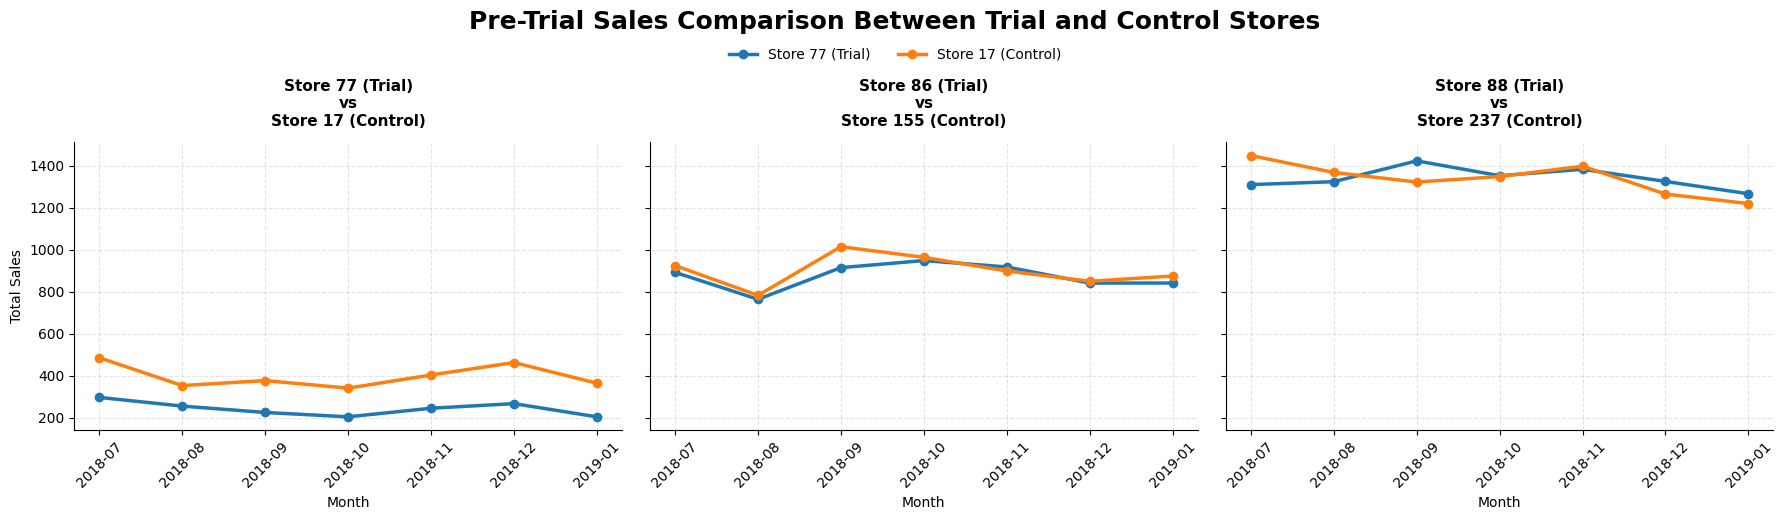

In [40]:
# ==========================================================
# Pre-Trial Sales Comparison
# Store 77 (Trial) vs Store 17 (Control)
# Store 86 (Trial) vs Store 155 (Control)
# Store 88 (Trial) vs Store 237 (Control)
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Pre-Trial Data
# ----------------------------------------------------------

pre_trial_sales = monthly_metrics[
    monthly_metrics["MONTH_ID"] < pd.Period("2019-02", freq="M")
].copy()

# Convert Period to string for display
pre_trial_sales["MONTH_ID"] = (
    pre_trial_sales["MONTH_ID"]
    .astype(str)
)

# ----------------------------------------------------------
# Trial-Control Store Pairs
# ----------------------------------------------------------

store_pairs = [
    (77, 17),
    (86, 155),
    (88, 237)
]

# ----------------------------------------------------------
# Create Figure
# ----------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5),
    sharey=True
)

# ----------------------------------------------------------
# Plot Each Store Pair
# ----------------------------------------------------------

for ax, (trial_store, control_store) in zip(axes, store_pairs):

    comparison = (
        pre_trial_sales[
            pre_trial_sales["STORE_NBR"].isin(
                [trial_store, control_store]
            )
        ]
        .pivot(
            index="MONTH_ID",
            columns="STORE_NBR",
            values="Total_Sales"
        )
        .reset_index()
    )

    # Trial Store
    ax.plot(
        comparison["MONTH_ID"],
        comparison[trial_store],
        marker="o",
        linewidth=2.5,
        label=f"Store {trial_store} (Trial)"
    )

    # Control Store
    ax.plot(
        comparison["MONTH_ID"],
        comparison[control_store],
        marker="o",
        linewidth=2.5,
        label=f"Store {control_store} (Control)"
    )

    # Subplot Title
    ax.set_title(
        f"Store {trial_store} (Trial)\nvs\nStore {control_store} (Control)",
        fontsize=11,
        fontweight="bold",
        pad=12
    )

    # X-axis
    ax.set_xlabel("Month")

    # Grid
    ax.grid(
        linestyle="--",
        alpha=0.35
    )

    # Rotate labels
    ax.tick_params(
        axis="x",
        rotation=45
    )

    # Remove top/right borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ----------------------------------------------------------
# Shared Labels
# ----------------------------------------------------------

axes[0].set_ylabel("Total Sales")

# ----------------------------------------------------------
# Main Title
# ----------------------------------------------------------

fig.suptitle(
    "Pre-Trial Sales Comparison Between Trial and Control Stores",
    fontsize=18,
    fontweight="bold",
    y=1.03
)

# ----------------------------------------------------------
# Single Legend
# ----------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 0.98),
    frameon=False
)

# ----------------------------------------------------------
# Layout
# ----------------------------------------------------------

plt.tight_layout()

plt.show()

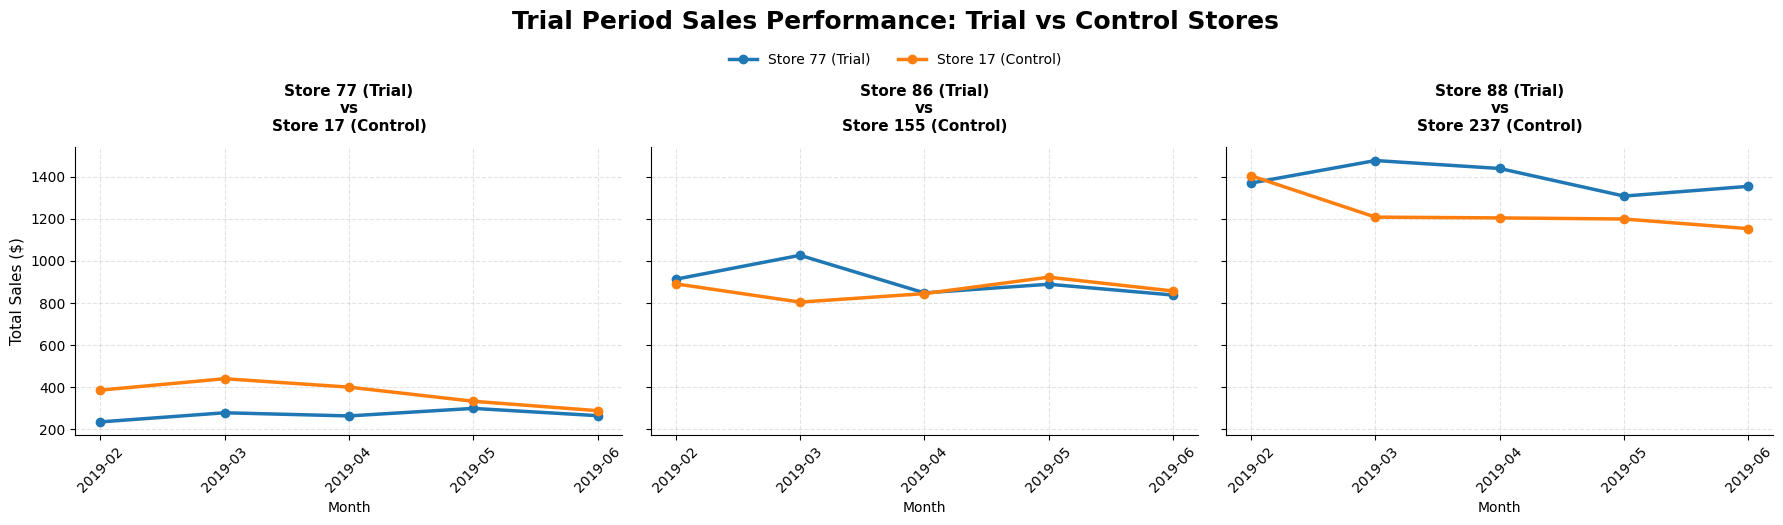

In [41]:
# ==========================================================
# Slide 9
# Trial Period Sales Comparison
# (Feb 2019 - Jun 2019)
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Trial Period Data
# ----------------------------------------------------------

trial_period_sales = monthly_metrics[
    monthly_metrics["MONTH_ID"] >= pd.Period("2019-02", freq="M")
].copy()

# Convert Period to string for x-axis labels
trial_period_sales["MONTH_ID"] = (
    trial_period_sales["MONTH_ID"]
    .astype(str)
)

# ----------------------------------------------------------
# Trial-Control Store Pairs
# ----------------------------------------------------------

store_pairs = [
    (77, 17),
    (86, 155),
    (88, 237)
]

# ----------------------------------------------------------
# Create Figure
# ----------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5),
    sharey=True
)

# ----------------------------------------------------------
# Plot Each Store Pair
# ----------------------------------------------------------

for ax, (trial_store, control_store) in zip(axes, store_pairs):

    comparison = (
        trial_period_sales[
            trial_period_sales["STORE_NBR"].isin(
                [trial_store, control_store]
            )
        ]
        .pivot(
            index="MONTH_ID",
            columns="STORE_NBR",
            values="Total_Sales"
        )
        .reset_index()
    )

    # Trial Store
    ax.plot(
        comparison["MONTH_ID"],
        comparison[trial_store],
        marker="o",
        linewidth=2.5,
        markersize=6,
        label=f"Store {trial_store} (Trial)"
    )

    # Control Store
    ax.plot(
        comparison["MONTH_ID"],
        comparison[control_store],
        marker="o",
        linewidth=2.5,
        markersize=6,
        label=f"Store {control_store} (Control)"
    )

    # Subplot Title
    ax.set_title(
        f"Store {trial_store} (Trial)\nvs\nStore {control_store} (Control)",
        fontsize=11,
        fontweight="bold",
        pad=12
    )

    # X-axis
    ax.set_xlabel("Month", fontsize=10)

    # Grid
    ax.grid(
        linestyle="--",
        alpha=0.35
    )

    # Rotate Month Labels
    ax.tick_params(
        axis="x",
        rotation=45
    )

    # Remove Borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ----------------------------------------------------------
# Shared Y-axis
# ----------------------------------------------------------

axes[0].set_ylabel(
    "Total Sales ($)",
    fontsize=11
)

# ----------------------------------------------------------
# Main Title
# ----------------------------------------------------------

fig.suptitle(
    "Trial Period Sales Performance: Trial vs Control Stores",
    fontsize=18,
    fontweight="bold",
    y=1.04
)

# ----------------------------------------------------------
# Common Legend
# ----------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=False
)

# ----------------------------------------------------------
# Adjust Layout
# ----------------------------------------------------------

plt.tight_layout()

plt.show()

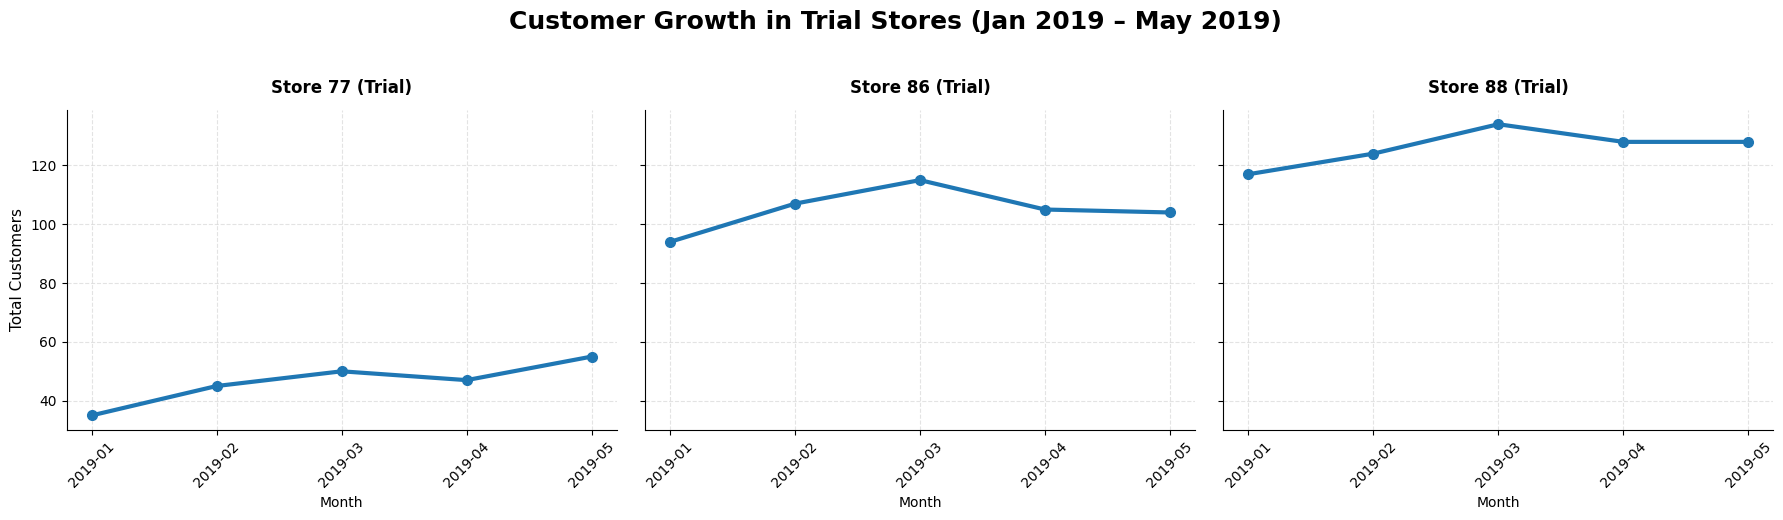

In [42]:
# ==========================================================
# Slide 10
# Customer Growth in Trial Stores
# (Jan 2019 - May 2019)
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Data (Jan 2019 - May 2019)
# ----------------------------------------------------------

customer_growth = monthly_metrics[
    (monthly_metrics["MONTH_ID"] >= pd.Period("2019-01", freq="M")) &
    (monthly_metrics["MONTH_ID"] <= pd.Period("2019-05", freq="M"))
].copy()

# Convert Period to string
customer_growth["MONTH_ID"] = customer_growth["MONTH_ID"].astype(str)

# ----------------------------------------------------------
# Trial Stores
# ----------------------------------------------------------

trial_stores = [77, 86, 88]

# ----------------------------------------------------------
# Create Figure
# ----------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5),
    sharey=True
)

# ----------------------------------------------------------
# Plot Customer Growth
# ----------------------------------------------------------

for ax, trial_store in zip(axes, trial_stores):

    data = (
        customer_growth[
            customer_growth["STORE_NBR"] == trial_store
        ]
        .sort_values("MONTH_ID")
    )

    ax.plot(
        data["MONTH_ID"],
        data["Total_Customers"],
        marker="o",
        linewidth=3,
        markersize=7,
        label=f"Store {trial_store} (Trial)"
    )

    ax.set_title(
        f"Store {trial_store} (Trial)",
        fontsize=12,
        fontweight="bold",
        pad=12
    )

    ax.set_xlabel("Month")

    ax.grid(
        linestyle="--",
        alpha=0.35
    )

    ax.tick_params(
        axis="x",
        rotation=45
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ----------------------------------------------------------
# Shared Y-axis
# ----------------------------------------------------------

axes[0].set_ylabel(
    "Total Customers",
    fontsize=11
)

# ----------------------------------------------------------
# Main Title
# ----------------------------------------------------------

fig.suptitle(
    "Customer Growth in Trial Stores (Jan 2019 – May 2019)",
    fontsize=18,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

plt.show()